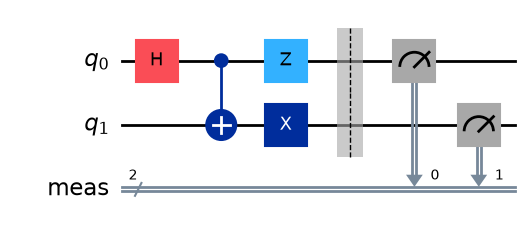

In [1]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService
import os
from dotenv import load_dotenv

bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)

bell.x(1)
bell.z(0)

bell.measure_all()  

bell.draw("mpl")

In [2]:
my_api_key = os.getenv("API_KEY")
QiskitRuntimeService.save_account(channel='ibm_quantum_platform',
                                   token=my_api_key,
                                      overwrite= True)

service = QiskitRuntimeService()

backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
print(backend.name)

qiskit_runtime_service.__init__:WARNING:2026-08-04 01:00:42,326: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: konstantina klei. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-08-04 01:00:42,781: Loading instance: konstantina klei, plan: open
qiskit_runtime_service.backends:WARNING:2026-08-04 01:00:45,794: Using instance: konstantina klei, plan: open


ibm_fez


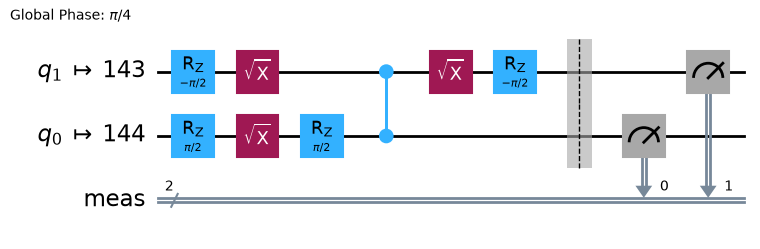

In [3]:
# Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
bell_isa = pm.run(bell)

bell_isa.draw("mpl")

In [4]:
# Load the Runtime primitive and session
sampler = Sampler(mode=backend)

In [5]:
from qiskit.primitives import BackendSamplerV2
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

noise_model = NoiseModel.from_backend(backend)

# Define a simulator using Aer, and use it in Sampler.
backend_sim = AerSimulator(noise_model=noise_model)
sampler_sim = BackendSamplerV2(backend=backend_sim)

# Alternatively, load a fake backend with generic properties and define a simulator.
# backend_gen = GenericBackendV2(num_qubits=15)
# sampler_gen = BackendSamplerV2(backend=backend_gen)

In [6]:
# job = sampler.run([bell_isa], shots=100)
job = sampler_sim.run([bell_isa]) # uncomment if you want to run on a simulator
res = job.result()
counts = res[0].data.meas.get_counts()

counts =  {'10': 508, '01': 509, '00': 3, '11': 4}


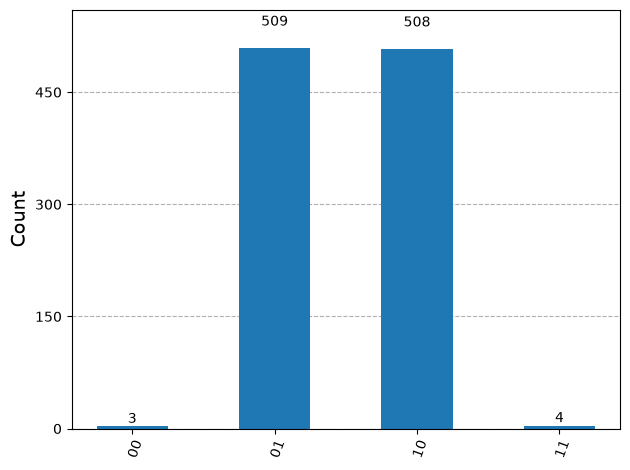

In [7]:
from qiskit.visualization import plot_histogram

print("counts = ", counts)
plot_histogram(counts)

 ## Modern quantum hardware is typically evaluated across three dimensions: scale, quality, and speed.
* Scale is measured by the number of programmable qubits available to users.
* Quality is measured by qubit operations (QuOps), which describe how many of the most computationally demanding quantum operations a system can reliably execute before accumulated errors overwhelm the computation
* Speed is measured by maximum circuits per second, also known as circuit throughput.
* * CLOPS (Circuit Layer Operations Per Second) and EPLG (Errors Per Layered Gate). CLOPS measures the execution speed of a standardized benchmark workload, while EPLG provides insight into gate-layer error rates and processor fidelity. 


## Πιθανοί Τομείς Εφαρμογής της Κβαντικής Υπολογιστικής

* Προσομοίωση Χαμιλτονιανής (Hamiltonian Simulation)
Αυτό το θέμα αφορά την προσομοίωση κβαντομηχανικών διεργασιών που βρίσκονται στη φύση. Στον πυρήνα του, περιλαμβάνει δύο βασικές εργασίες: την εύρεση της ενέργειας θεμελιώδους κατάστασης ενός συστήματος που περιγράφεται από τη Χαμιλτονιανή του (η οποία κωδικοποιεί τη συνολική ενέργεια και τις αλληλεπιδράσεις εντός του συστήματος) και την προσομοίωση του τρόπου με τον οποίο αυτό το σύστημα εξελίσσεται στον χρόνο (κβαντική δυναμική).

* Βελτιστοποίηση (Optimization)
Τα προβλήματα βελτιστοποίησης περιλαμβάνουν την εύρεση της καλύτερης λύσης από ένα μεγάλο σύνολο πιθανών λύσεων, υπό συγκεκριμένους περιορισμούς. Αυτά τα προβλήματα εμφανίζονται στην επιστήμη, τη μηχανική και τη βιομηχανία, και συχνά γίνονται υπολογιστικά ανεπίλυτα καθώς το μέγεθος του προβλήματος μεγαλώνει.

* * Χρονοπρογραμματισμό και δρομολόγηση (π.χ. εφοδιαστικές αλυσίδες, ροή κυκλοφορίας, προγραμματισμός πτήσεων αερογραμμών).

* * Βελτιστοποίηση χαρτοφυλακίου και διαχείριση κινδύνου (χρηματοοικονομικά).

* * Κατανομή πόρων και logistics.

* * Συνδυαστικά προβλήματα, όπως ο διαμερισμός γραφημάτων (graph partitioning) και το max-cut.

Πολλά προβλήματα βελτιστοποίησης ταξινομούνται ως NP-hard στη θεωρία

* Μερικές Διαφορικές Εξισώσεις (PDEs)
Οι μερικές διαφορικές εξισώσεις περιγράφουν πώς αλλάζουν οι φυσικές ποσότητες στον χώρο και τον χρόνο. Αποτελούν τη βάση για πολλά από τα πιο σημαντικά μοντέλα στην επιστήμη και τη μηχανική, συμπεριλαμβανομένης της δυναμικής των ρευστών, του ηλεκτρομαγνητισμού, της μεταφοράς θερμότητας και της χρηματοοικονομικής μοντελοποίησης.

* * Εξισώσεις Navier–Stokes για τη ροή ρευστών.

* * Εξισώσεις Schrödinger και κυματικές εξισώσεις.

* * Εξισώσεις του Maxwell.

* * Black–Scholes και σχετικές χρηματοοικονομικές PDEs.

* * Η αarithmetic επίλυση των PDEs σε κλασικούς υπολογιστές απαιτεί συχνά πυκνά χωρικά πλέγματα και μακρές χρονικές εξελίξεις, οδηγώντας σε υψηλό υπολογιστικό κόστος και χρήση μνήμης.

* Μηχανική Μάθηση (Machine Learning)
Η Κβαντική Μηχανική Μάθηση (QML) εξερευνά πώς οι κβαντικοί υπολογιστές ενδέχεται να βελτιώσουν ή να επιταχύνουν πτυχές της μηχανικής μάθησης και της ανάλυσης δεδομένων. Αυτό περιλαμβάνει και τα δύο από τα ακόλουθα:

* * Τη χρήση κβαντικών υπολογιστών για την εξερεύνηση προβλημάτων ταξινόμησης με διαφορετική συμπεριφορά ταξινόμησης από τους κλασικούς αλγόριθμους.

* * Την ανάπτυξη νέων μοντέλων που είναι εγγενώς κβαντικά στη φύση τους.

* * Οι προτεινόμενες εφαρμογές περιλαμβάνουν τα εξής:

* * Ταξινόμηση (classification) και ομαδοποίηση (clustering).

* * Μεθόδους πυρήνα (kernel methods) και χάρτες χαρακτηριστικών (feature maps).

* * Υπορουτίνες βελτιστοποίησης εντός των βρόχων εκπαίδευσης.




H=J * Z|1>Ζ|0> +h(X|1> +X |0>)


In [9]:
from qiskit.quantum_info import SparsePauliOp

J = 1.0  # η σταθερά αλληλεπίδρασης (coupling constant) μεταξύ γειτονικών spin στο σύστημα. Καθορίζει πόσο δυνατά επηρεάζει το ένα spin το γειτονικό του.
hx = -0.5  # transverse field strength

obs = SparsePauliOp.from_list([("ZZ", J), ("XI", hx), ("IX", hx)])

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)
qc.z(0)

* ("ZZ", J): Αντιπροσωπεύει την αλληλεπίδραση J * Z τανυστικο  Z μεταξύ του 0-οστού και του 1-ου qubit.
* ("XI", hx): Εφαρμόζει το εγκάρσιο πεδίο hx στο 1-ο qubit (X τανυστικο I).
* ("IX", hx): Εφαρμόζει το εγκάρσιο πεδίο hx στο 0-ο qubit (I τανυστικο X).

* Όταν J > 0, η ζεύξη είναι σιδηρομαγνητική (ferromagnetic): τα γειτονικά spin προτιμούν να ευθυγραμμιστούν στην ίδια κατεύθυνση (↑ ↑ ή ↓ ↓) για να ελαχιστοποιήσουν την ενέργεια.
* Όταν $J < 0$, η ζεύξη είναι αντισιδηρομαγνητική (antiferromagnetic): τα spin προτιμούν να κοιτούν σε αντίθετες κατευθύνσεις (↑ ↓).

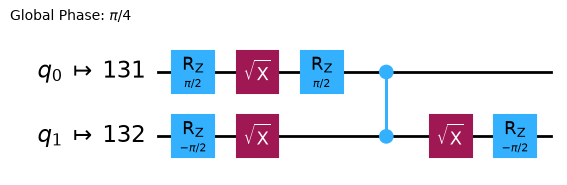

In [10]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)
obs_isa = obs.apply_layout(layout=qc_isa.layout)

qc_isa.draw("mpl")

In [11]:
from qiskit_ibm_runtime import EstimatorV2 as Estimator

estimator = Estimator(mode=backend)

In [12]:
from qiskit.primitives import BackendEstimatorV2
# backend sampler

# noise_model = NoiseModel.from_backend(backend)

# Use Aer simulator in Estimator
estimator_sim = BackendEstimatorV2(backend=backend_sim)

# Alternatively, load a fake backend with generic properties and define a simulator.
# backend_gen = GenericBackendV2(num_qubits=18)
# estimator_gen = BackendEstimatorV2(backend=backend_gen)

In [20]:
from qiskit_aer import AerSimulator
from qiskit.primitives import BackendEstimatorV2

# simulator βασισμένου στο backend της IBM
aer_backend = AerSimulator.from_backend(backend)

# Δημιουργία του estimator με αυτόν τον simulator
estimator_sim = BackendEstimatorV2(backend=aer_backend)
pubs = [(qc_isa, obs_isa)]
job = estimator_sim.run(pubs)
res = job.result()

In [21]:
print(res[0].data.evs)

-0.85693359375


In [22]:
print("Expectation Value:", res[0].data.evs)
print("Standard Error:", res[0].data.stds)

Expectation Value: -0.85693359375
Standard Error: 0.023665814502998872


# Το νούμερο -0.8701 εκφράζει την αναμενόμενη τιμή ενέργειας της κβαντικής κατάστασης Bell.
* Θεωρητικά, η ιδανική τιμή είναι -1.0 (αφού <ZZ> = -1.0 και <XI> = <IX> = 0).
* Η απόκλιση κατά 0.12988 οφείλεται στην προσομοίωση του πραγματικού επεξεργαστή της IBM, ο οποίος εισάγει κβαντικό θόρυβο και στο στατιστικό σφάλμα από τις πεπερασμένες μετρήσεις (shots).